In [ ]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt

from mne import read_source_spaces
from mne.source_estimate import SourceEstimate

from func.configs import ATLAS, AUDLANG_NET
from func.utils import combine_labels

plt.rcParams["font.family"] = "Arial"

# Directories
BIDS_ROOT = "./data/bids/SMN4Lang"
SUBJECTS_DIR = os.path.join(BIDS_ROOT, "freesurfer")
SUBJECT = "fsaverage"
SPACING = "ico3"
NUM_VERTEX_DICT = {
    "ico3" : 1284,
    "ico4" : 5124,
    "ico5" : 20484,
}
NUM_VERTEX = NUM_VERTEX_DICT[SPACING]

In [2]:
src = read_source_spaces(os.path.join(SUBJECTS_DIR, f"{SUBJECT}/bem/{SUBJECT}-{SPACING}-src.fif"))

label = combine_labels(SUBJECT, SUBJECTS_DIR, ATLAS, AUDLANG_NET)
label = label.restrict(src)

if label.hemi == "lh":
    label_vertices = label.get_vertices_used(np.arange(0, NUM_VERTEX//2))
elif label.hemi == "rh":
    label_vertices = label.get_vertices_used(np.arange(0, NUM_VERTEX//2)) + NUM_VERTEX//2 

    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
Reading labels from parcellation...
   read 75 labels from c:\Users\DELL\Desktop\COGSCI\data\bids\SMN4Lang\freesurfer\fsaverage\label\lh.aparc.a2009s.annot
   read 75 labels from c:\Users\DELL\Desktop\COGSCI\data\bids\SMN4Lang\freesurfer\fsaverage\label\rh.aparc.a2009s.annot


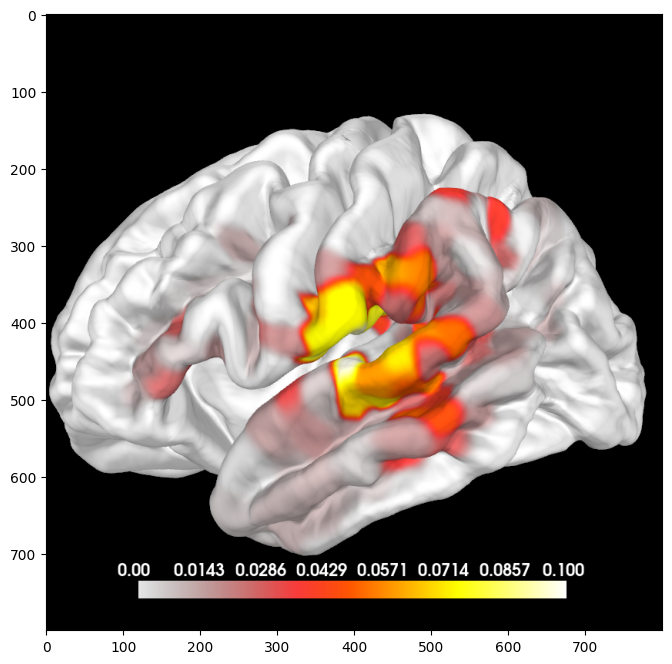

In [ ]:
results = np.load("whisper-speech_context-1000_r-obs.npy")

vertices_data = np.zeros((NUM_VERTEX,))
vertices_data[label_vertices] = results
vertices_data = np.expand_dims(vertices_data, axis=1)

stc = SourceEstimate(
    data=vertices_data,
    vertices=[src[0]["vertno"], src[1]["vertno"]],
    tmin=0,
    tstep=1,
    subject=SUBJECT
)

brain = stc.plot(
    subjects_dir=SUBJECTS_DIR,
    subject=SUBJECT,
    views="lat",
    hemi=label.hemi,
    size=(800, 800),
    initial_time=0,
    smoothing_steps=15,
    time_viewer=False,
    colormap="hot",
    clim={"kind": "value", "lims":[0.0, 0.05, 0.1]},
    transparent=True,
    cortex=[0.9, 0.9, 0.9],
    surface="pial",
)

screenshot = brain.screenshot()
brain.close()

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(screenshot)

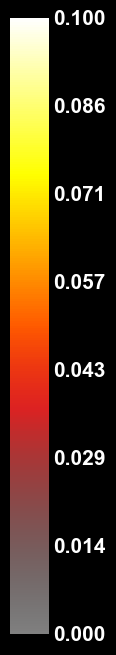

In [ ]:
fig, ax = plt.subplots(figsize=(0.5, 8))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

cbar = mne.viz.plot_brain_colorbar(
    ax=ax,
    clim={"kind": "value", "lims":[0.0, 0.05, 0.1]},
    colormap="hot",
    orientation="vertical",
    label="",
    bgcolor="0.5"
)

ticks = [0, 0.0143, 0.0286, 0.0429, 0.0571, 0.0714, 0.0857, 0.100]
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{t:.3f}" for t in ticks])

cbar.ax.yaxis.set_tick_params(color="white", length=0)
for label in cbar.ax.get_yticklabels():
    label.set_color("white")
    label.set_fontsize(15)
    label.set_fontweight("bold")

plt.show()